# 05 RSU Intersection Stress Test

This notebook visualizes the second scenario (RSU at an intersection).

- Input:
  - `result/table/05_rsu_intersection_timeseries.csv`
  - `result/table/05_rsu_intersection_summary.csv`
- Output:
  - PDF vector figures in `result/figure/`
  - summary tables in `result/table/`


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# -----------------------------------------------------------------------------
# Fix: Handle paths for both Script (.py) and Jupyter Notebook (.ipynb)
# -----------------------------------------------------------------------------
try:
    # This works when running as a script
    current_path = Path(__file__).resolve()
    ROOT = current_path.parents[1]
except NameError:
    # This works in Jupyter Notebook
    current_path = Path.cwd()
    ROOT = current_path.parents[0]

# Verify the path is correct
print(f"Current ROOT: {ROOT}")

tbl_dir = ROOT / "result" / "table"
fig_dir = ROOT / "result" / "figure"
fig_dir.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# Load Data
# -----------------------------------------------------------------------------
timeseries_csv = tbl_dir / "05_rsu_intersection_timeseries.csv"
summary_csv = tbl_dir / "05_rsu_intersection_summary.csv"

if timeseries_csv.exists() and summary_csv.exists():
    df_ts = pd.read_csv(timeseries_csv)
    df_sum = pd.read_csv(summary_csv)
    methods = list(df_sum["method"].unique())
    print("Methods:", methods)
else:
    if not timeseries_csv.exists():
        print(f"Error: File not found at {timeseries_csv}")
    if not summary_csv.exists():
        print(f"Error: File not found at {summary_csv}")


Current ROOT: /home/leiyo/GitHub/TOAH
Methods: ['TOAH', 'Fixed-SensingLeader', 'Fixed-CommLeader', 'TOAH-NoHG', 'HeuristicGate', 'AO-Heuristic']


In [2]:
# Summary table: mean ± std across runs for each method
metrics = ["avg_sum_queue", "p95_max_queue", "avg_sense_u", "p95_sense_u",
           "alpha_total_variation", "switch_count", "deadline_violation_rate", "avg_slot_ms"]

agg = df_sum.groupby("method")[metrics].agg(["mean", "std"]).reset_index()
agg.columns = ["method"] + [f"{m}_{s}" for m in metrics for s in ["mean", "std"]]

out_table = tbl_dir / "05_rsu_intersection_table.csv"
agg.to_csv(out_table, index=False)
print("Saved table:", out_table)

agg


Saved table: /home/leiyo/GitHub/TOAH/result/table/05_rsu_intersection_table.csv


,method,avg_sum_queue_mean,avg_sum_queue_std,p95_max_queue_mean,p95_max_queue_std,avg_sense_u_mean,avg_sense_u_std,p95_sense_u_mean,p95_sense_u_std,alpha_total_variation_mean,alpha_total_variation_std,switch_count_mean,switch_count_std,deadline_violation_rate_mean,deadline_violation_rate_std,avg_slot_ms_mean,avg_slot_ms_std
0,AO-Heuristic,2391.202441,37.364620,1505.387500,37.194598,0.033882,0.010520,0.090045,0.018736,1.000000,0.000000,1.0,0.000000,0.9678,0.002280,1278.150314,11.893007
1,Fixed-CommLeader,2394.554785,37.382731,1508.752197,37.325331,3.159535,2.898333,11.027581,12.236781,0.000000,0.000000,0.0,0.000000,0.9678,0.002280,1473.468649,27.416239
2,Fixed-SensingLeader,2394.595996,37.395738,1508.639282,37.326192,0.716219,0.251284,2.858815,0.665177,0.000000,0.000000,0.0,0.000000,0.9678,0.002280,1300.402242,29.267009
3,HeuristicGate,2394.486182,37.361165,1508.529590,37.175044,5.973083,7.226276,20.606675,26.303572,1.000000,0.000000,1.0,0.000000,0.9678,0.002280,1466.752765,11.498694
4,TOAH,2365.564941,NaN,1240.762744,120.071262,0.493693,NaN,4.495093,3.587199,0.523886,NaN,1.8,0.447214,0.6878,0.154968,2738.649505,36.099868
5,TOAH-NoHG,2394.594482,37.409184,1508.653003,37.340883,2.504230,4.172325,18.223632,33.042009,0.528046,0.016081,1.0,0.000000,0.9678,0.002280,31.626232,2.564429


Saved: /home/leiyo/GitHub/TOAH/result/figure/05_rsu_timeseries_sum_queue.pdf
Saved: /home/leiyo/GitHub/TOAH/result/figure/05_rsu_timeseries_sense_u.pdf
Saved: /home/leiyo/GitHub/TOAH/result/figure/05_rsu_timeseries_alpha.pdf


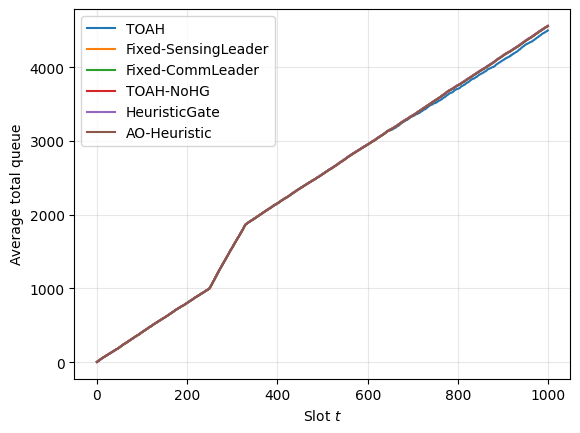

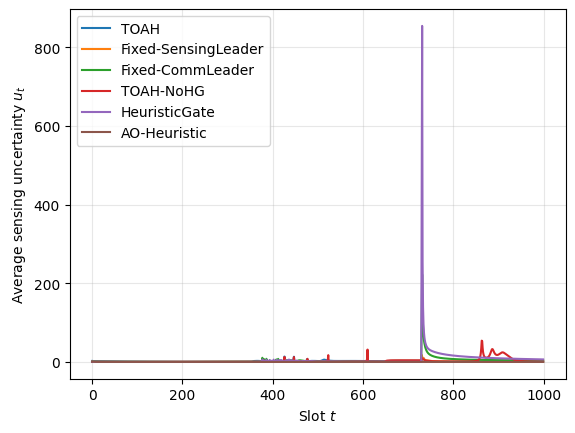

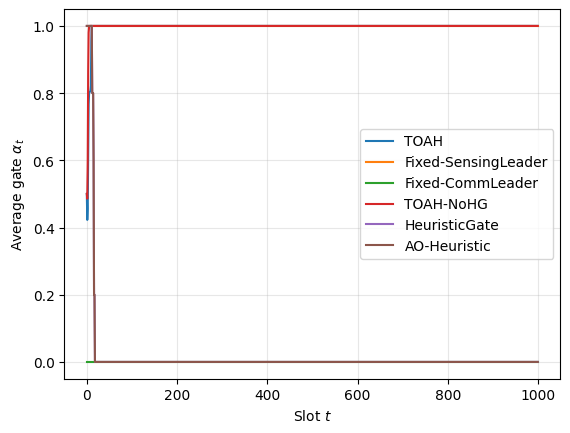

In [4]:
# Time-series (mean across runs) for queue and sensing
g = df_ts.groupby(["method", "t"], as_index=False).agg(
    sum_queue=("sum_queue", "mean"),
    max_queue=("max_queue", "mean"),
    sense_u=("sense_u", "mean"),
    alpha=("alpha", "mean"),
)

def plot_metric(metric: str, ylabel: str, fname: str):
    plt.figure()
    for m in methods:
        sub = g[g["method"] == m]
        plt.plot(sub["t"], sub[metric], label=m)
    plt.xlabel("Slot $t$")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, alpha=0.3)
    out = fig_dir / fname
    plt.savefig(out, format="pdf", bbox_inches="tight")
    print("Saved:", out)

plot_metric("sum_queue", "Average total queue", "05_rsu_timeseries_sum_queue.pdf")
plot_metric("sense_u", "Average sensing uncertainty $u_t$", "05_rsu_timeseries_sense_u.pdf")
plot_metric("alpha", r"Average gate $\alpha_t$", "05_rsu_timeseries_alpha.pdf")


Saved: /home/leiyo/GitHub/TOAH/result/figure/05_rsu_cdf_max_queue.pdf


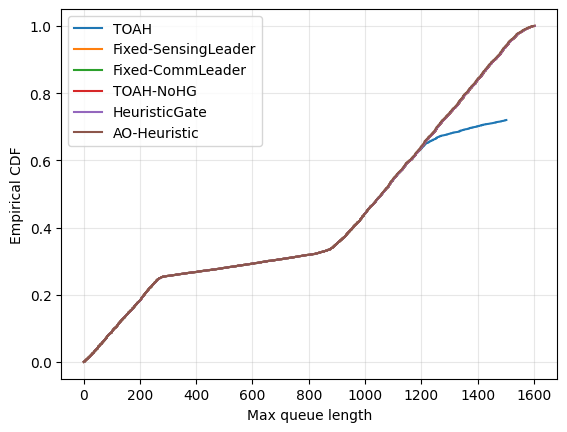

In [5]:
# Empirical CDF of max queue (across all slots and runs)
plt.figure()
for m in methods:
    vals = df_ts[df_ts["method"] == m]["max_queue"].values
    xs = np.sort(vals)
    ys = np.linspace(0, 1, len(xs), endpoint=True)
    plt.plot(xs, ys, label=m)
plt.xlabel("Max queue length")
plt.ylabel("Empirical CDF")
plt.legend()
plt.grid(True, alpha=0.3)
out = fig_dir / "05_rsu_cdf_max_queue.pdf"
plt.savefig(out, format="pdf", bbox_inches="tight")
print("Saved:", out)


Saved: /home/leiyo/GitHub/TOAH/result/figure/05_rsu_boxplot_slot_ms.pdf


/tmp/ipykernel_27491/3828069653.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=methods, vert=True, showfliers=False)


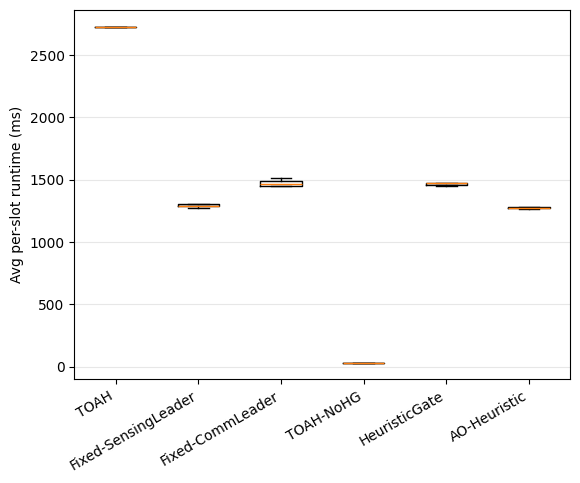

In [6]:
# Boxplot: per-run avg slot time for each method
data = [df_sum[df_sum["method"] == m]["avg_slot_ms"].values for m in methods]
plt.figure()
plt.boxplot(data, labels=methods, vert=True, showfliers=False)
plt.ylabel("Avg per-slot runtime (ms)")
plt.xticks(rotation=30, ha="right")
plt.grid(True, axis="y", alpha=0.3)
out = fig_dir / "05_rsu_boxplot_slot_ms.pdf"
plt.savefig(out, format="pdf", bbox_inches="tight")
print("Saved:", out)
